# 08 — Análisis de resultados

## Objetivo

Visualizar la distribución de escenarios y analizar el
comportamiento estadístico de la simulación Monte Carlo.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
simulation_data = pd.read_csv(
    PROJECT_ROOT
    / "results"
    / "tables"
    / "sequential_simulation.csv"
)

final_values = (
    simulation_data["final_value"]
    .to_numpy()
)

final_returns = (
    simulation_data["final_return"]
    .to_numpy()
)

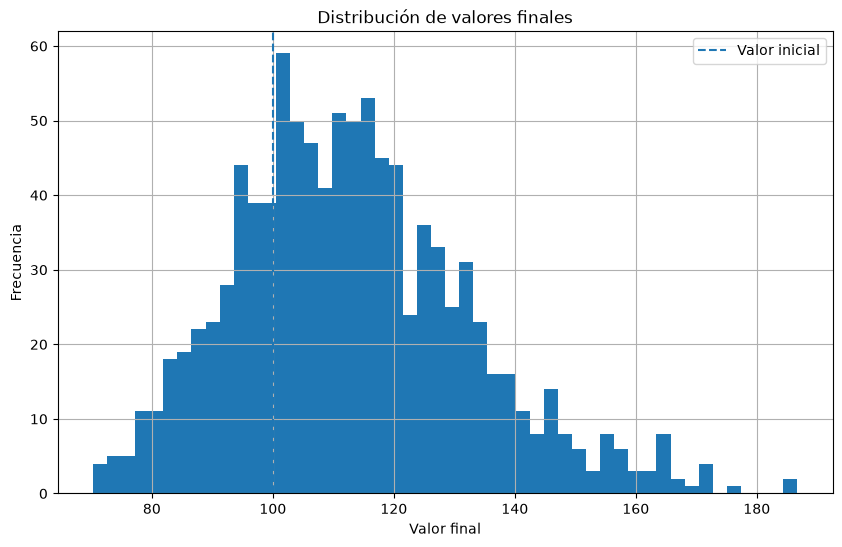

In [4]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_values,
    bins=50,
)

plt.axvline(
    100,
    linestyle="--",
    label="Valor inicial",
)

plt.title(
    "Distribución de valores finales"
)

plt.xlabel(
    "Valor final"
)

plt.ylabel(
    "Frecuencia"
)

plt.legend()

plt.grid(True)

plt.show()

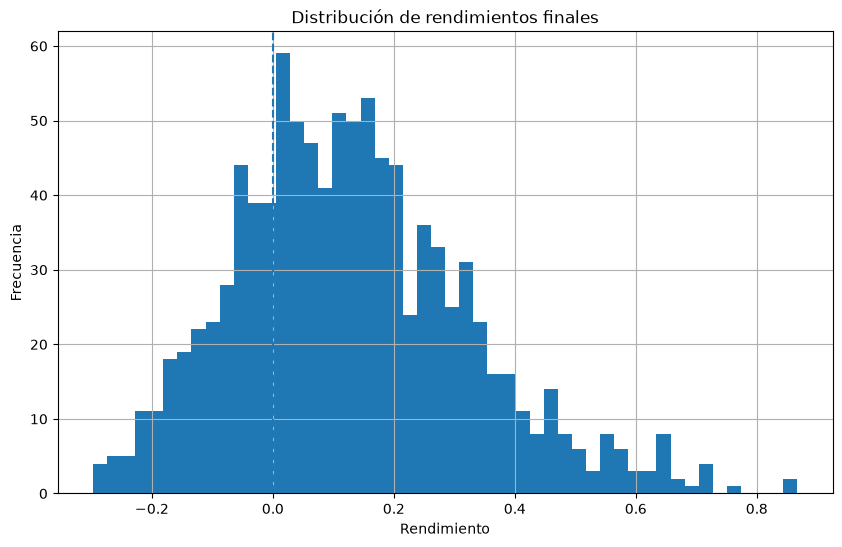

In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_returns,
    bins=50,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.title(
    "Distribución de rendimientos finales"
)

plt.xlabel(
    "Rendimiento"
)

plt.ylabel(
    "Frecuencia"
)

plt.grid(True)

plt.show()

In [6]:
percentiles = np.percentile(
    final_values,
    [1, 5, 25, 50, 75, 95, 99],
)

percentile_table = pd.DataFrame(
    {
        "percentile": [
            "1%",
            "5%",
            "25%",
            "50%",
            "75%",
            "95%",
            "99%",
        ],
        "value": percentiles,
    }
)

percentile_table

,percentile,value
0,1%,75.038500
1,5%,84.096203
2,25%,99.489410
3,50%,111.247042
4,75%,125.064852
5,95%,147.951328
6,99%,165.746138


In [7]:
worst_value = np.min(
    final_values
)

best_value = np.max(
    final_values
)

print(
    f"Peor escenario: {worst_value:.4f}"
)

print(
    f"Mejor escenario: {best_value:.4f}"
)

Peor escenario: 70.2447
Mejor escenario: 186.7135


## Interpretación

La distribución permite observar la dispersión de resultados
generados bajo los supuestos del modelo.

Los escenarios extremos no deben interpretarse como predicciones
deterministas, sino como resultados pertenecientes al conjunto
de escenarios simulados.